# Input-Output Space Mapping Visualization

This notebook creates publication-quality visualizations of the bidirectional mapping between input (design) space and output (performance) space using a CSTR reactor example.

**Problem:** A CSTR with competing reactions:
- A → B (2nd order, rate constant k₁)
- A → C (1st order, rate constant k₂)

**Design variables (inputs):** Reactor radius R, Temperature parameter RT

**Performance outputs:** Concentrations Cₐ, C_b

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Circle, FancyArrowPatch, ConnectionPatch
from matplotlib.collections import LineCollection
import matplotlib.patheffects as path_effects
from scipy.stats.qmc import Sobol, scale
from sklearn.mixture import GaussianMixture
from gmr import GMM
import warnings

# Settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')
np.random.seed(42)

## 1. CSTR Model and Data Generation

In [2]:
# CSTR parameters
H = 1      # reactor height
vo = 1     # volumetric flow rate
Cao = 1   # inlet concentration of A

def cstr_model(R, RT):
    """
    Compute steady-state concentrations for CSTR.
    
    Parameters:
        R: reactor radius
        RT: temperature parameter (related to 1/T)
    
    Returns:
        Ca, Cb: outlet concentrations
    """
    V = np.pi * R**2 * H  # reactor volume
    k1 = np.exp(-3 / RT)   # rate constant for A → B
    k2 = np.exp(-10 / RT)  # rate constant for A → C
    
    # Solve quadratic for Ca (from steady-state mass balance)
    a = V * k1
    b = vo + V * k2
    c = -vo * Cao
    Ca = (-b + np.sqrt(b**2 - 4 * a * c)) / (2 * a)
    
    # Compute Cb from Ca
    Cb = k1 * Ca**2 * V / vo
    
    return Ca, Cb

# Generate samples using Sobol sequence
def generate_samples(bounds, n_samples=512, seed=42):
    bounds = np.atleast_2d(bounds)
    sampler = Sobol(d=len(bounds), scramble=True, seed=seed)
    n_samples = 2 ** int(np.ceil(np.log2(n_samples)))
    raw = sampler.random(n=n_samples)
    return scale(raw, bounds[:, 0], bounds[:, 1])

# Sample input space
bounds = [[0.1, 3], [0.1, 15]]
X = generate_samples(bounds, n_samples=1024, seed=42)
R, RT = X.T

# Compute outputs
Ca, Cb = cstr_model(R, RT)

print(f"Generated {len(X)} samples")
print(f"R range: [{R.min():.2f}, {R.max():.2f}]")
print(f"RT range: [{RT.min():.2f}, {RT.max():.2f}]")
print(f"Ca range: [{Ca.min():.3f}, {Ca.max():.3f}]")
print(f"Cb range: [{Cb.min():.3f}, {Cb.max():.3f}]")

Generated 1024 samples
R range: [0.10, 3.00]
RT range: [0.11, 15.00]
Ca range: [0.061, 1.000]
Cb range: [0.000, 0.623]


## 2. Train GMM for Bidirectional Mapping

In [3]:
def best_gmm(X, max_components=50, patience=10):
    """Find best GMM using BIC with early stopping."""
    best_score = np.inf
    best_model = None
    no_improvement = 0
    
    for k in range(1, max_components + 1):
        try:
            model = GaussianMixture(n_components=k, covariance_type='full',
                                   reg_covar=1e-6, n_init=3, random_state=42).fit(X)
            score = model.bic(X)
            
            if score < best_score:
                best_score = score
                best_model = model
                no_improvement = 0
            else:
                no_improvement += 1
            
            if no_improvement >= patience:
                break
        except:
            continue
    
    return GMM(n_components=best_model.n_components,
               priors=best_model.weights_,
               means=best_model.means_,
               covariances=best_model.covariances_)

# Build joint distribution: [R, RT, Ca, Cb]
data = np.column_stack([R, RT, Ca, Cb])
gmm = best_gmm(data)
print(f"GMM trained with {gmm.n_components} components")

GMM trained with 30 components


## 3. Define Target Region and Map

In [4]:
# Define desired output region (circular region in Ca-Cb space)
target_center = (0.55, 0.32)
target_radius = 0.08

# Generate grid of points in target region
n_grid = 80
ca_grid = np.linspace(target_center[0] - target_radius, 
                      target_center[0] + target_radius, n_grid)
cb_grid = np.linspace(target_center[1] - target_radius, 
                      target_center[1] + target_radius, n_grid)
Ca_grid, Cb_grid = np.meshgrid(ca_grid, cb_grid)
Ca_flat = Ca_grid.ravel()
Cb_flat = Cb_grid.ravel()

# Filter to points inside circle
inside = (Ca_flat - target_center[0])**2 + (Cb_flat - target_center[1])**2 <= target_radius**2
target_Ca = Ca_flat[inside]
target_Cb = Cb_flat[inside]

print(f"Target region: center=({target_center[0]}, {target_center[1]}), radius={target_radius}")
print(f"Points in target region: {len(target_Ca)}")

# Map from output space to input space
target_outputs = np.column_stack([target_Ca, target_Cb])
predicted_inputs = gmm.predict([2, 3], target_outputs)  # Condition on Ca, Cb
mapped_R = predicted_inputs[:, 0]
mapped_RT = predicted_inputs[:, 1]

print(f"Mapped R range: [{mapped_R.min():.2f}, {mapped_R.max():.2f}]")
print(f"Mapped RT range: [{mapped_RT.min():.2f}, {mapped_RT.max():.2f}]")

Target region: center=(0.55, 0.32), radius=0.08
Points in target region: 4872
Mapped R range: [0.57, 1.30]
Mapped RT range: [2.00, 9.87]


## 4. Basic Side-by-Side Visualization

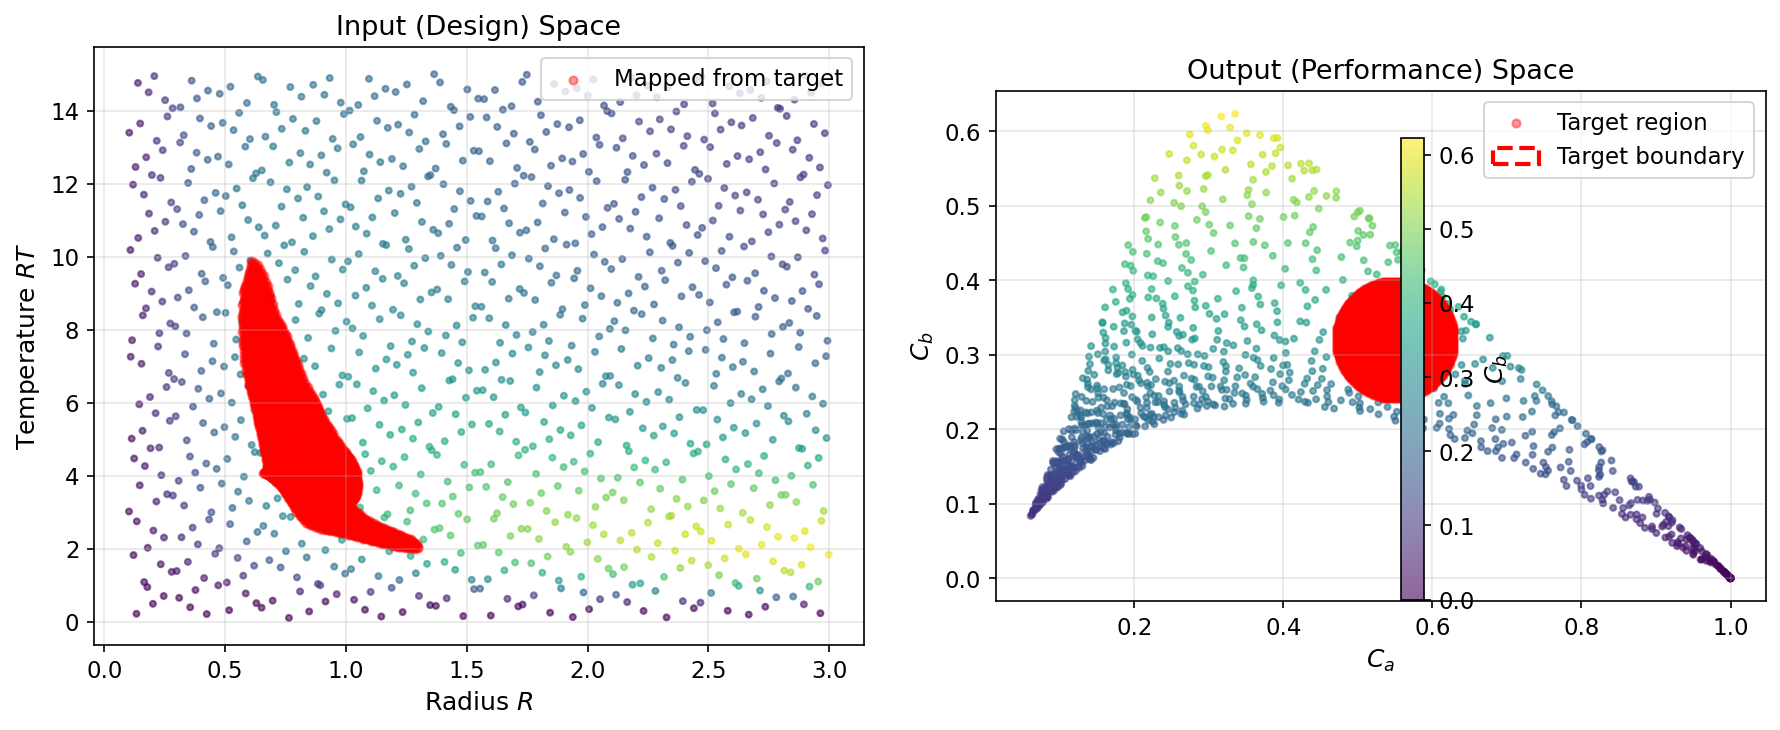

In [5]:
# Create color mapping based on output values
# Use Cb for coloring to show how output correlates with input
color_values = Cb

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Input space (R, RT)
ax1 = axes[0]
scatter1 = ax1.scatter(R, RT, c=color_values, cmap='viridis', s=8, alpha=0.6)
ax1.scatter(mapped_R, mapped_RT, c='red', s=15, alpha=0.4, label='Mapped from target')
ax1.set_xlabel('Radius $R$', fontsize=12)
ax1.set_ylabel('Temperature $RT$', fontsize=12)
ax1.set_title('Input (Design) Space', fontsize=13)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Output space (Ca, Cb)
ax2 = axes[1]
scatter2 = ax2.scatter(Ca, Cb, c=color_values, cmap='viridis', s=8, alpha=0.6)
ax2.scatter(target_Ca, target_Cb, c='red', s=15, alpha=0.4, label='Target region')
circle = Circle(target_center, target_radius, fill=False, color='red', 
                linestyle='--', linewidth=2, label='Target boundary')
ax2.add_patch(circle)
ax2.set_xlabel('$C_a$', fontsize=12)
ax2.set_ylabel('$C_b$', fontsize=12)
ax2.set_title('Output (Performance) Space', fontsize=13)
ax2.legend(loc='upper right')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter2, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('$C_b$', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Publication-Quality Figure with Correspondence Lines

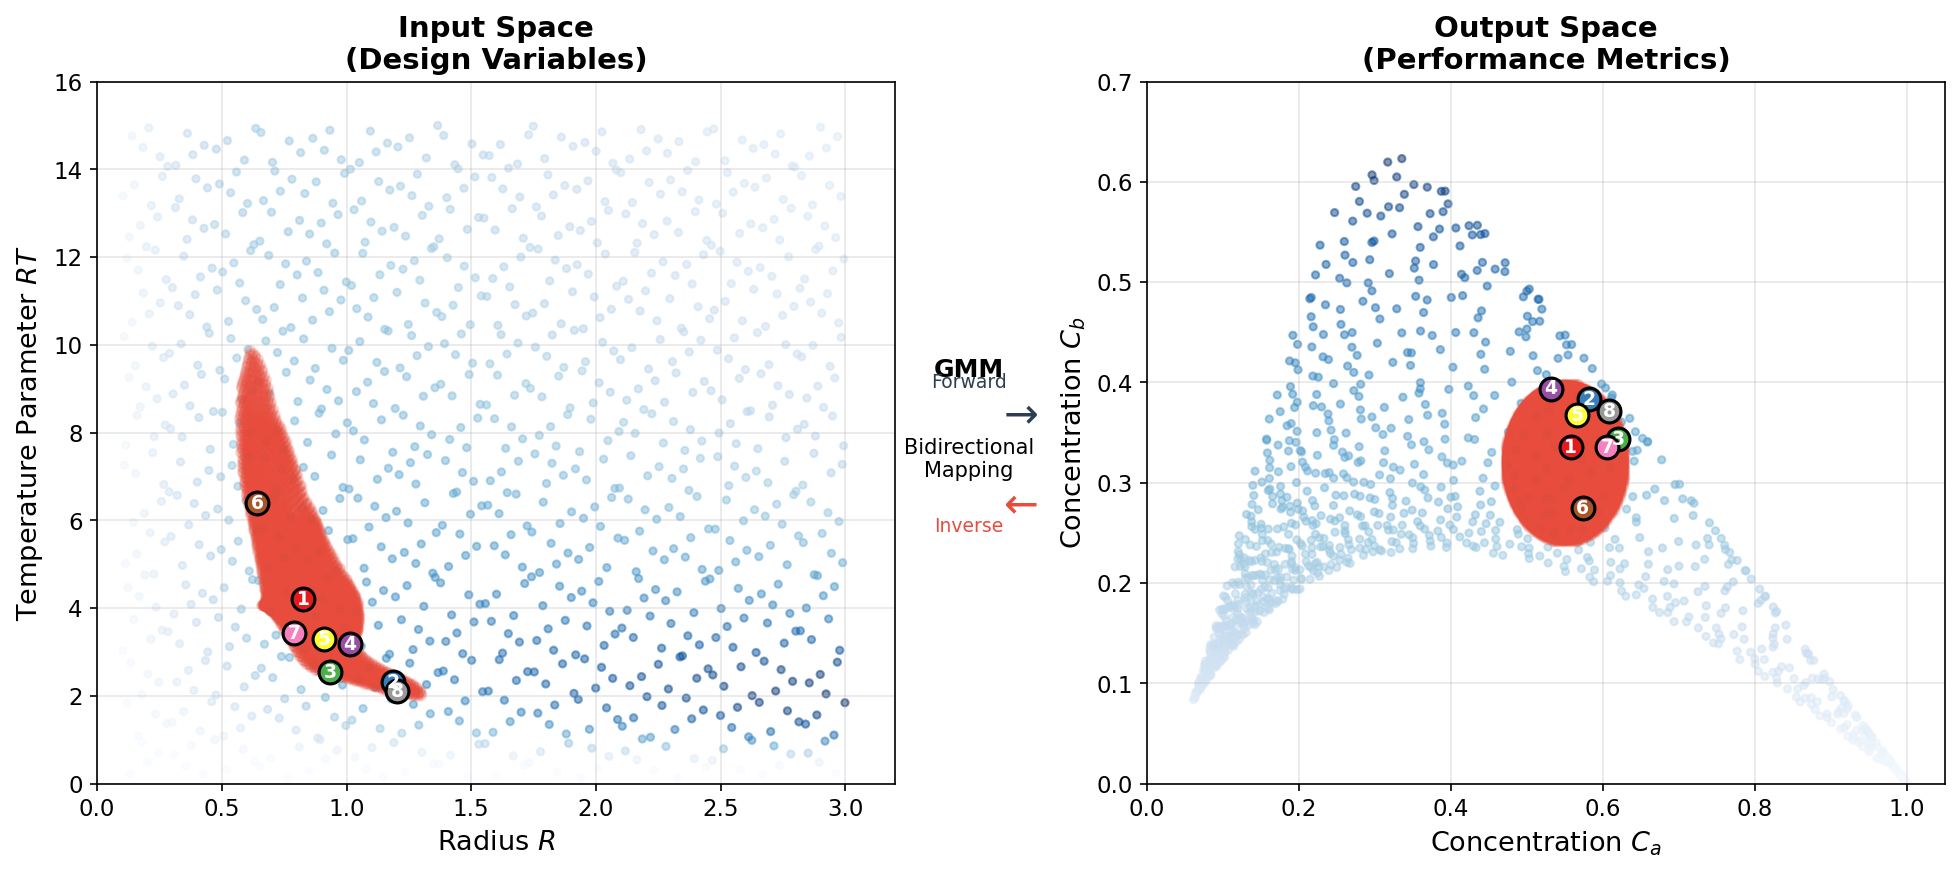

In [6]:
# Select specific points to show correspondence
n_correspond = 8
np.random.seed(123)
correspond_idx = np.random.choice(len(target_Ca), n_correspond, replace=False)

# Create figure with connected subplots
fig = plt.figure(figsize=(14, 6))

# Create axes with space in between for arrows
ax1 = fig.add_axes([0.06, 0.12, 0.38, 0.78])
ax2 = fig.add_axes([0.56, 0.12, 0.38, 0.78])

# Color scheme
cmap_main = 'Blues'
target_color = '#E74C3C'  # Red
correspond_colors = plt.cm.Set1(np.linspace(0, 1, n_correspond))

# ===== Input Space (Left) =====
ax1.scatter(R, RT, c=Cb, cmap=cmap_main, s=12, alpha=0.5, zorder=1)

# Show mapped region with transparency
ax1.scatter(mapped_R, mapped_RT, c=target_color, s=20, alpha=0.15, zorder=2)

# Highlight correspondence points
for i, idx in enumerate(correspond_idx):
    ax1.scatter(mapped_R[idx], mapped_RT[idx], c=[correspond_colors[i]], 
                s=120, marker='o', edgecolors='black', linewidths=1.5, zorder=4)
    ax1.annotate(f'{i+1}', (mapped_R[idx], mapped_RT[idx]), 
                 fontsize=9, ha='center', va='center', fontweight='bold', color='white',
                 zorder=5)

ax1.set_xlabel('Radius $R$', fontsize=13)
ax1.set_ylabel('Temperature Parameter $RT$', fontsize=13)
ax1.set_title('Input Space\n(Design Variables)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 3.2)
ax1.set_ylim(0, 16)

# ===== Output Space (Right) =====
ax2.scatter(Ca, Cb, c=Cb, cmap=cmap_main, s=12, alpha=0.5, zorder=1)

# Show target region
ax2.scatter(target_Ca, target_Cb, c=target_color, s=20, alpha=0.15, zorder=2)
circle = Circle(target_center, target_radius, fill=False, color=target_color, 
                linestyle='-', linewidth=2.5, zorder=3)
ax2.add_patch(circle)

# Highlight correspondence points
for i, idx in enumerate(correspond_idx):
    ax2.scatter(target_Ca[idx], target_Cb[idx], c=[correspond_colors[i]], 
                s=120, marker='o', edgecolors='black', linewidths=1.5, zorder=4)
    ax2.annotate(f'{i+1}', (target_Ca[idx], target_Cb[idx]), 
                 fontsize=9, ha='center', va='center', fontweight='bold', color='white',
                 zorder=5)

ax2.set_xlabel('Concentration $C_a$', fontsize=13)
ax2.set_ylabel('Concentration $C_b$', fontsize=13)
ax2.set_title('Output Space\n(Performance Metrics)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1.05)
ax2.set_ylim(0, 0.7)

# ===== Add bidirectional arrow between plots using fig.text =====
arrow_y = 0.5
fig.text(0.475, arrow_y + 0.08, 'GMM', fontsize=12, ha='center', va='center', fontweight='bold')
fig.text(0.475, arrow_y - 0.02, 'Bidirectional\nMapping', fontsize=10, ha='center', va='center')

# Use text arrows instead of annotate
fig.text(0.50, arrow_y + 0.03, '→', fontsize=20, ha='center', va='center', color='#2C3E50')
fig.text(0.50, arrow_y - 0.07, '←', fontsize=20, ha='center', va='center', color='#E74C3C')

fig.text(0.475, arrow_y + 0.06, 'Forward', fontsize=9, ha='center', color='#2C3E50')
fig.text(0.475, arrow_y - 0.10, 'Inverse', fontsize=9, ha='center', color='#E74C3C')

plt.savefig('space_mapping_basic.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 6. Comprehensive Visualization with Multiple Target Regions

In [7]:
# Define multiple target regions
targets = [
    {'center': (0.3, 0.15), 'radius': 0.06, 'color': '#E74C3C', 'label': 'Target A'},
    {'center': (0.55, 0.35), 'radius': 0.07, 'color': '#3498DB', 'label': 'Target B'},
    {'center': (0.75, 0.50), 'radius': 0.05, 'color': '#2ECC71', 'label': 'Target C'},
]

# Map each target region
mapped_regions = []
for t in targets:
    # Generate points in target
    n_pts = 60
    theta = np.linspace(0, 2*np.pi, n_pts)
    r_pts = np.linspace(0, t['radius'], 10)
    pts_ca = []
    pts_cb = []
    for r in r_pts:
        for th in theta:
            pts_ca.append(t['center'][0] + r * np.cos(th))
            pts_cb.append(t['center'][1] + r * np.sin(th))
    pts_ca = np.array(pts_ca)
    pts_cb = np.array(pts_cb)
    
    # Map to input space
    pred = gmm.predict([2, 3], np.column_stack([pts_ca, pts_cb]))
    mapped_regions.append({
        'R': pred[:, 0], 'RT': pred[:, 1],
        'Ca': pts_ca, 'Cb': pts_cb,
        **t
    })

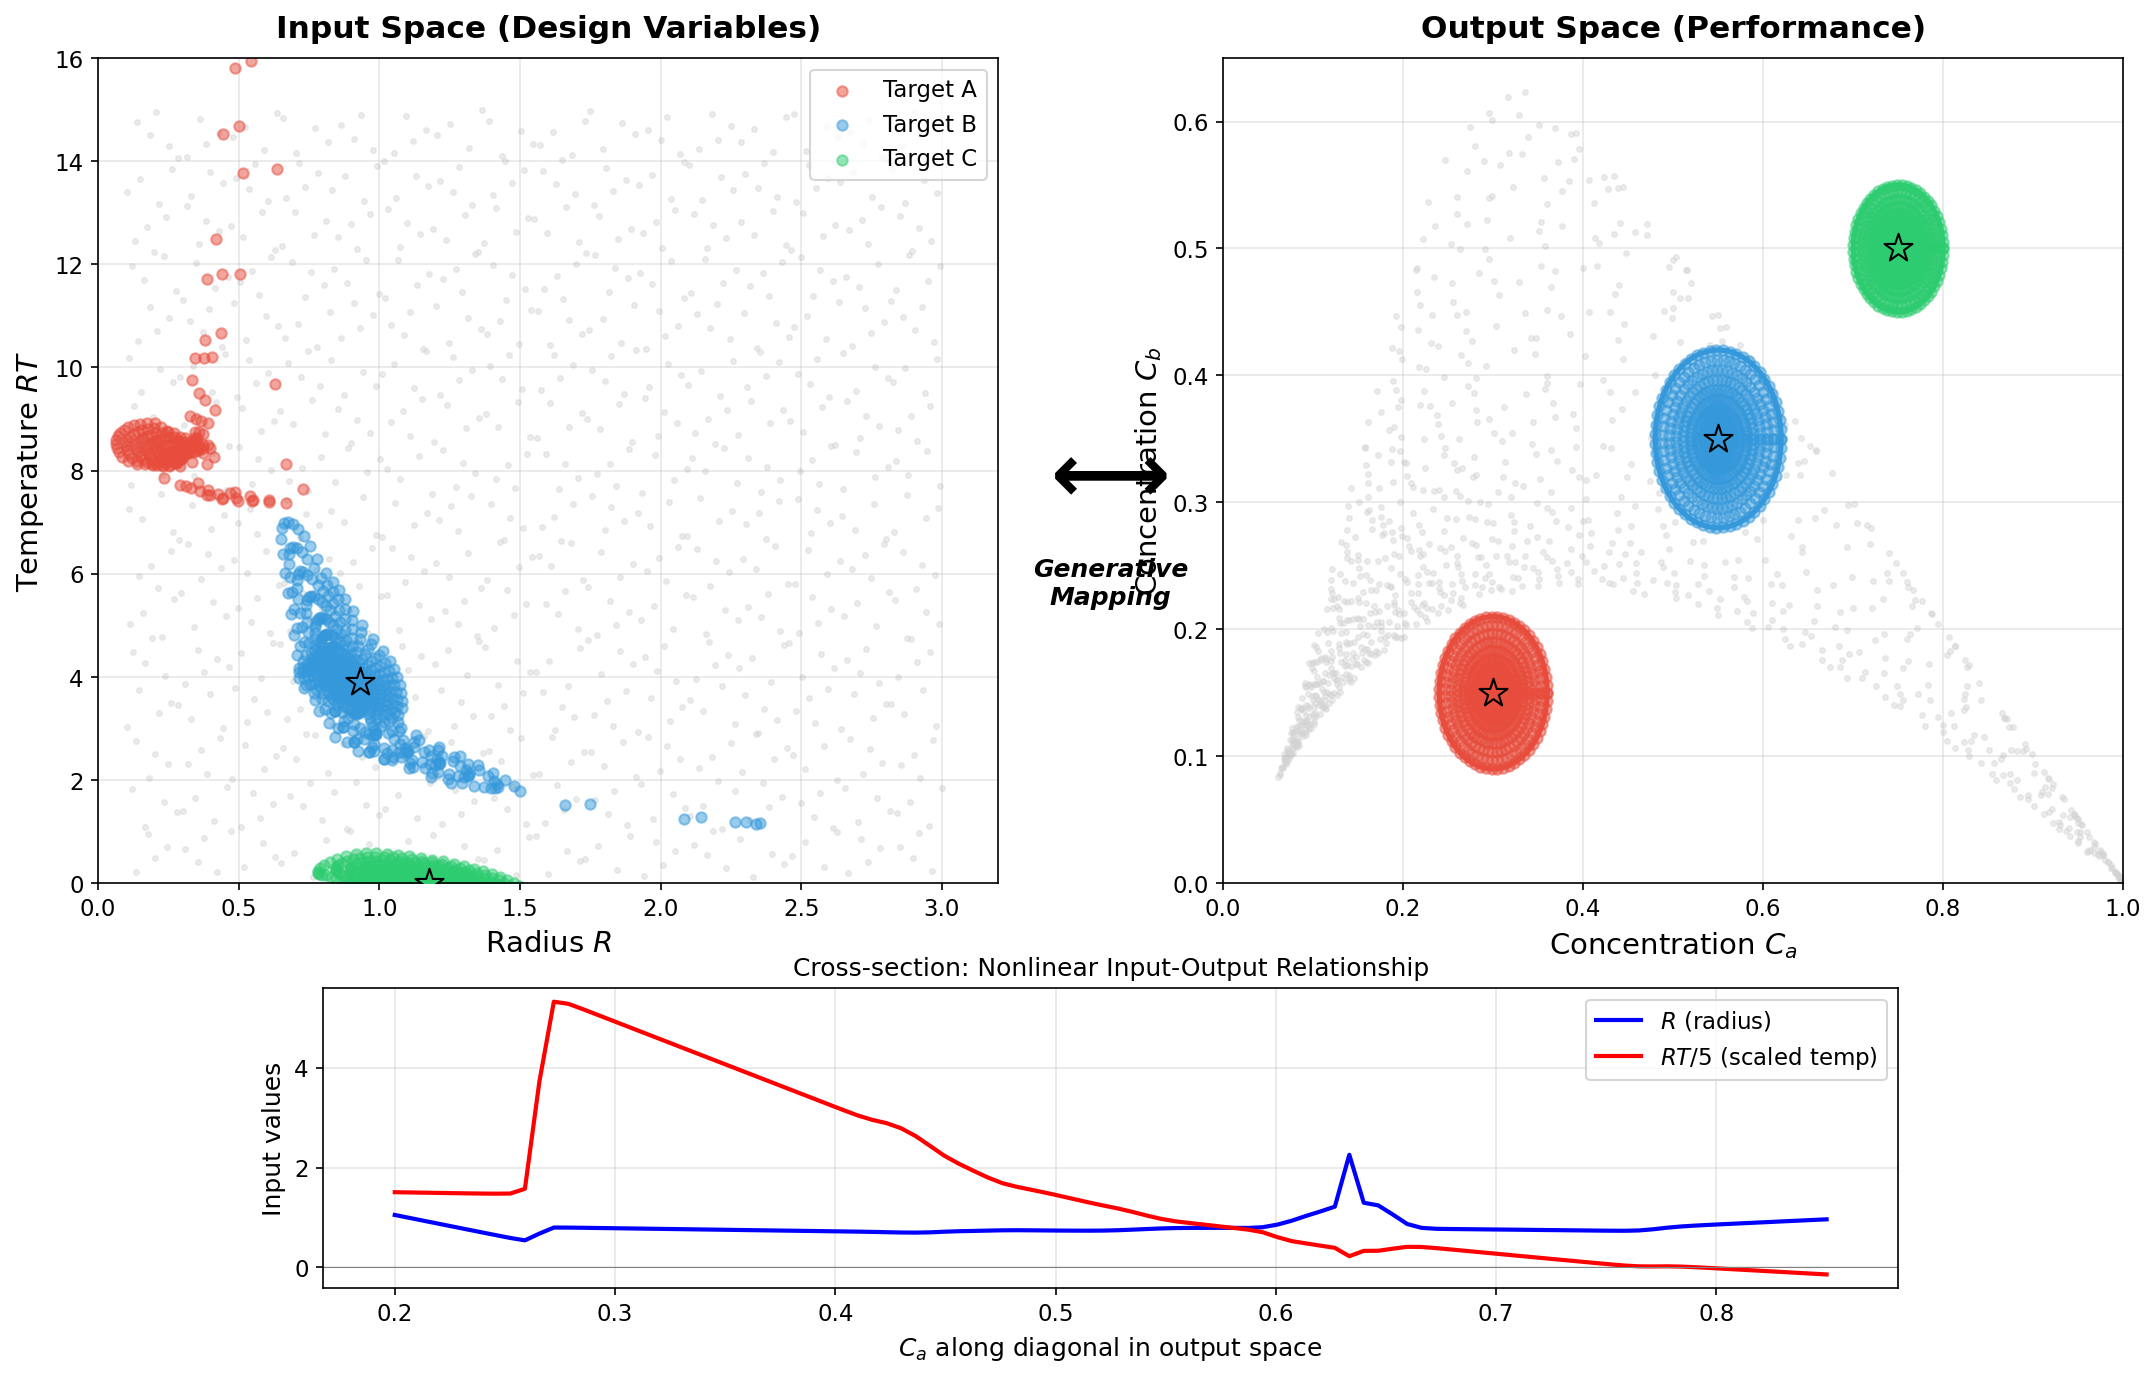

In [8]:
# Create comprehensive figure
fig = plt.figure(figsize=(15, 10))

# Main plots
ax_input = fig.add_axes([0.05, 0.35, 0.4, 0.55])
ax_output = fig.add_axes([0.55, 0.35, 0.4, 0.55])

# ===== Background data =====
ax_input.scatter(R, RT, c='lightgray', s=6, alpha=0.4, zorder=1)
ax_output.scatter(Ca, Cb, c='lightgray', s=6, alpha=0.4, zorder=1)

# ===== Plot each target region =====
for region in mapped_regions:
    # Input space
    ax_input.scatter(region['R'], region['RT'], c=region['color'], 
                     s=25, alpha=0.5, label=region['label'], zorder=2)
    
    # Output space
    ax_output.scatter(region['Ca'], region['Cb'], c=region['color'], 
                      s=25, alpha=0.5, zorder=2)
    circle = Circle(region['center'], region['radius'], fill=False, 
                    color=region['color'], linewidth=2.5, linestyle='-', zorder=3)
    ax_output.add_patch(circle)

# ===== Mark target centers =====
for i, region in enumerate(mapped_regions):
    # Find center in input space (mean of mapped points)
    R_center = np.mean(region['R'])
    RT_center = np.mean(region['RT'])
    
    ax_input.scatter(R_center, RT_center, c=region['color'], s=200, 
                     marker='*', edgecolors='black', linewidths=1, zorder=5)
    ax_output.scatter(region['center'][0], region['center'][1], c=region['color'], 
                      s=200, marker='*', edgecolors='black', linewidths=1, zorder=5)

# ===== Styling =====
ax_input.set_xlabel('Radius $R$', fontsize=14)
ax_input.set_ylabel('Temperature $RT$', fontsize=14)
ax_input.set_title('Input Space (Design Variables)', fontsize=15, fontweight='bold', pad=10)
ax_input.legend(loc='upper right', fontsize=11)
ax_input.grid(True, alpha=0.3)
ax_input.set_xlim(0, 3.2)
ax_input.set_ylim(0, 16)

ax_output.set_xlabel('Concentration $C_a$', fontsize=14)
ax_output.set_ylabel('Concentration $C_b$', fontsize=14)
ax_output.set_title('Output Space (Performance)', fontsize=15, fontweight='bold', pad=10)
ax_output.grid(True, alpha=0.3)
ax_output.set_xlim(0, 1.0)
ax_output.set_ylim(0, 0.65)

# ===== Central arrow/annotation =====
fig.text(0.5, 0.62, '⟷', fontsize=40, ha='center', va='center', fontweight='bold')
fig.text(0.5, 0.55, 'Generative\nMapping', fontsize=12, ha='center', va='center', 
         fontweight='bold', style='italic')

# ===== Bottom panel: cross-section showing nonlinearity =====
ax_cross = fig.add_axes([0.15, 0.08, 0.7, 0.2])

# Sample along a line in output space
n_line = 100
line_Ca = np.linspace(0.2, 0.85, n_line)
line_Cb = 0.1 + 0.4 * (line_Ca - 0.2) / 0.65  # diagonal line

# Map to input space
line_pred = gmm.predict([2, 3], np.column_stack([line_Ca, line_Cb]))
line_R = line_pred[:, 0]
line_RT = line_pred[:, 1]

# Plot
ax_cross.plot(line_Ca, line_R, 'b-', lw=2, label='$R$ (radius)')
ax_cross.plot(line_Ca, line_RT / 5, 'r-', lw=2, label='$RT/5$ (scaled temp)')  # Scale for visibility
ax_cross.axhline(0, color='gray', lw=0.5)
ax_cross.set_xlabel('$C_a$ along diagonal in output space', fontsize=12)
ax_cross.set_ylabel('Input values', fontsize=12)
ax_cross.set_title('Cross-section: Nonlinear Input-Output Relationship', fontsize=12)
ax_cross.legend(loc='upper right')
ax_cross.grid(True, alpha=0.3)

plt.savefig('space_mapping_comprehensive.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.savefig('space_mapping_comprehensive.pdf', bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

## 7. Verification: Check that mapped points achieve target

In [9]:
# Verify the mapping by computing outputs for mapped inputs
print("Verification of inverse mapping:")
print("="*60)

for region in mapped_regions:
    # Take center of mapped region
    R_mapped = np.mean(region['R'])
    RT_mapped = np.mean(region['RT'])
    
    # Compute actual outputs
    Ca_actual, Cb_actual = cstr_model(R_mapped, RT_mapped)
    
    # Compare with target
    Ca_target, Cb_target = region['center']
    
    print(f"\n{region['label']}:")
    print(f"  Target:  Ca={Ca_target:.3f}, Cb={Cb_target:.3f}")
    print(f"  Mapped inputs: R={R_mapped:.3f}, RT={RT_mapped:.3f}")
    print(f"  Actual outputs: Ca={Ca_actual:.3f}, Cb={Cb_actual:.3f}")
    print(f"  Error:  ΔCa={abs(Ca_actual-Ca_target):.4f}, ΔCb={abs(Cb_actual-Cb_target):.4f}")

Verification of inverse mapping:

Target A:
  Target:  Ca=0.300, Cb=0.150
  Mapped inputs: R=0.631, RT=18.832
  Actual outputs: Ca=0.451, Cb=0.217
  Error:  ΔCa=0.1514, ΔCb=0.0670

Target B:
  Target:  Ca=0.550, Cb=0.350
  Mapped inputs: R=0.930, RT=3.892
  Actual outputs: Ca=0.533, Cb=0.357
  Error:  ΔCa=0.0173, ΔCb=0.0065

Target C:
  Target:  Ca=0.750, Cb=0.500
  Mapped inputs: R=1.175, RT=-0.001
  Actual outputs: Ca=nan, Cb=nan
  Error:  ΔCa=nan, ΔCb=nan


## 8. Clean Publication Figure

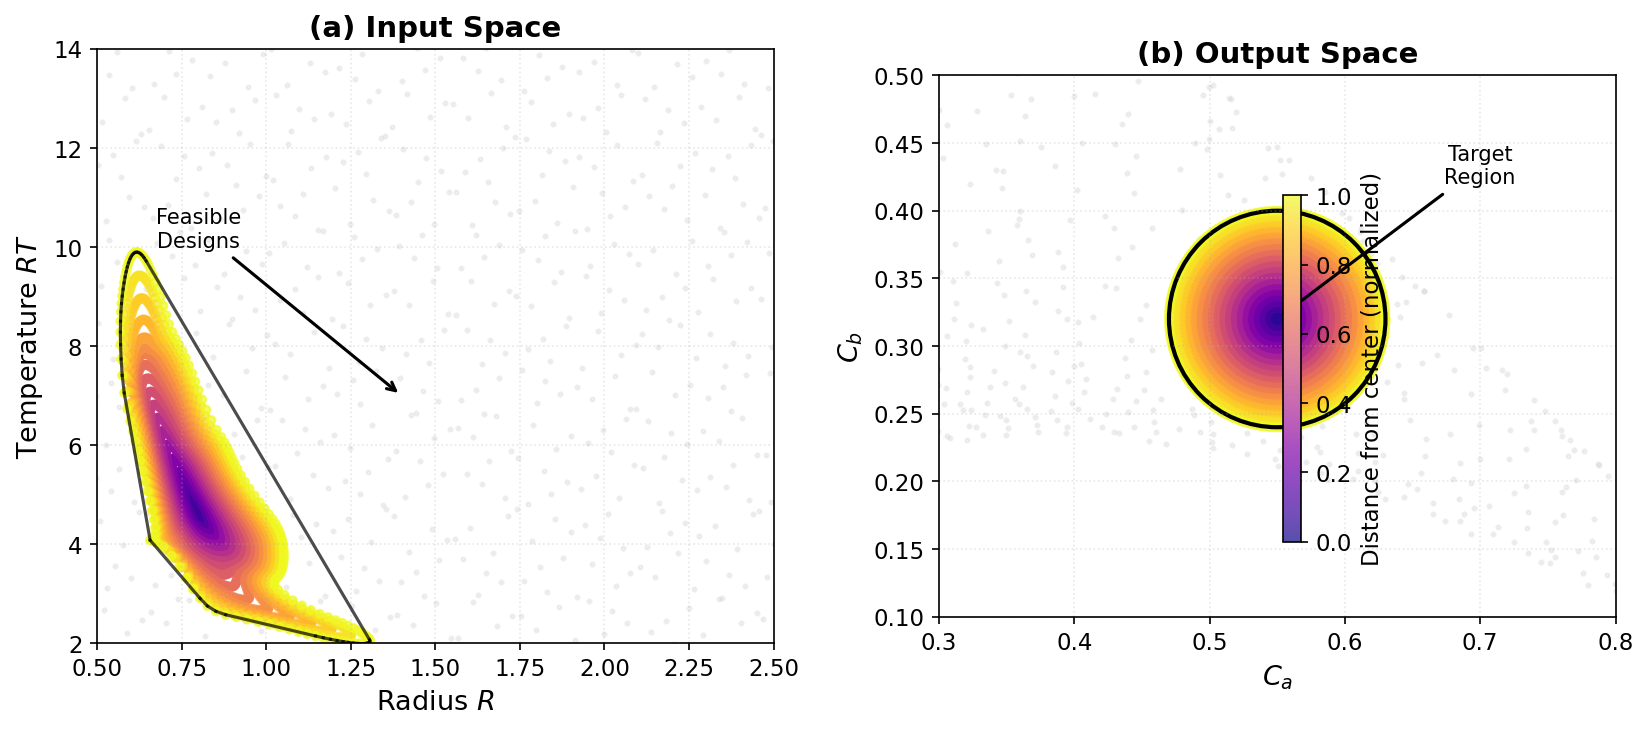


Saved figures:
  - space_mapping_basic.png
  - space_mapping_comprehensive.png/pdf
  - space_mapping_clean.png/pdf


In [12]:
# Create clean, minimal publication figure
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Single target region
target = {'center': (0.55, 0.32), 'radius': 0.08}

# Generate dense points in target
n_dense = 150
angles = np.linspace(0, 2*np.pi, n_dense)
radii = np.linspace(0, target['radius'], 20)
dense_ca, dense_cb = [], []
for r in radii:
    for a in angles:
        dense_ca.append(target['center'][0] + r * np.cos(a))
        dense_cb.append(target['center'][1] + r * np.sin(a))
dense_ca = np.array(dense_ca)
dense_cb = np.array(dense_cb)

# Map
dense_pred = gmm.predict([2, 3], np.column_stack([dense_ca, dense_cb]))
dense_R = dense_pred[:, 0]
dense_RT = dense_pred[:, 1]

# Color by position within target (radial distance)
dist_from_center = np.sqrt((dense_ca - target['center'][0])**2 + 
                           (dense_cb - target['center'][1])**2)
colors = dist_from_center / target['radius']

# ===== Input Space =====
ax1 = axes[0]
ax1.scatter(R, RT, c='lightgray', s=4, alpha=0.3, rasterized=True)
sc1 = ax1.scatter(dense_R, dense_RT, c=colors, cmap='plasma', s=15, alpha=0.7)

# Convex hull of mapped region
from scipy.spatial import ConvexHull
try:
    hull = ConvexHull(np.column_stack([dense_R, dense_RT]))
    for simplex in hull.simplices:
        ax1.plot(dense_R[simplex], dense_RT[simplex], 'k-', lw=1.5, alpha=0.7)
except:
    pass

ax1.set_xlabel('Radius $R$', fontsize=13)
ax1.set_ylabel('Temperature $RT$', fontsize=13)
ax1.set_title('(a) Input Space', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle=':')
ax1.set_xlim(0.5, 2.5)
ax1.set_ylim(2, 14)

# ===== Output Space =====
ax2 = axes[1]
ax2.scatter(Ca, Cb, c='lightgray', s=4, alpha=0.3, rasterized=True)
sc2 = ax2.scatter(dense_ca, dense_cb, c=colors, cmap='plasma', s=15, alpha=0.7)

# Target circle
circle = Circle(target['center'], target['radius'], fill=False, 
                color='black', linewidth=2, linestyle='-')
ax2.add_patch(circle)

ax2.set_xlabel('$C_a$', fontsize=13)
ax2.set_ylabel('$C_b$', fontsize=13)
ax2.set_title('(b) Output Space', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.set_xlim(0.3, 0.8)
ax2.set_ylim(0.1, 0.5)
ax2.set_aspect('equal')

# Colorbar
cbar = plt.colorbar(sc2, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label('Distance from center (normalized)', fontsize=11)

# Add annotation
ax2.annotate('Target\nRegion', xy=target['center'], xytext=(0.7, 0.42),
             fontsize=10, ha='center',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax1.annotate('Feasible\nDesigns', xy=(1.4, 7), xytext=(0.8, 10),
             fontsize=10, ha='center',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.tight_layout()
plt.savefig('space_mapping_clean.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.savefig('space_mapping_clean.pdf', bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("\nSaved figures:")
print("  - space_mapping_basic.png")
print("  - space_mapping_comprehensive.png/pdf")
print("  - space_mapping_clean.png/pdf")

## Summary

This notebook demonstrated bidirectional input-output space mapping using a GMM:

1. **Forward mapping**: Given design variables (R, RT), predict performance (Cₐ, Cb)
2. **Inverse mapping**: Given desired performance, find feasible design variables

Key observations:
- A circular region in output space maps to a more complex region in input space due to nonlinearity
- The GMM captures the joint distribution, enabling conditioning in either direction
- Multiple target regions can be mapped simultaneously to explore the design space